# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 24 - 2do bimestre 2026

Alumno: Martin Gabriel Quiroga

Legajo: a2412

Este tercer y último TP se debe entregar hasta las **23:59hs del viernes 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/56R6couXZBPDZzfs5)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

In [2]:
import gdown
import zipfile
import os

url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = '/content/datos_zip/dataset_emociones/train'
DATASET_ROOT_VAL   = '/content/datos_zip/dataset_emociones/validation'


Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=b792a62d-1e87-4387-aebf-03cb879888de
To: c:\CEIA\TercerBimestre\AP\aprendizaje_profundo_ceia\TPs\TP3\archivo.zip
100%|██████████| 40.0M/40.0M [00:01<00:00, 25.9MB/s]


## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



#### Resolución

Análisis de balance de clases
 - alegria: 4772 imágenes
 - disgusto: 717 imágenes
 - enojo: 705 imágenes
 - miedo: 281 imágenes
 - seriedad: 2524 imágenes
 - sorpresa: 1290 imágenes
 - tristeza: 1982 imágenes


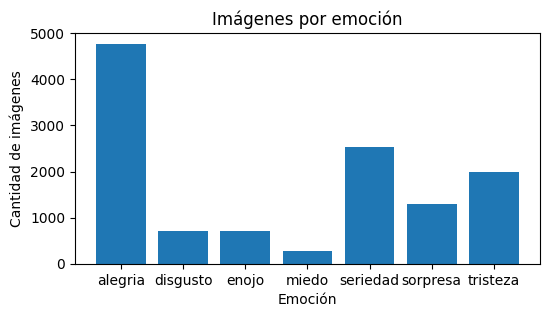

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Local
DATASET_ROOT_TRAIN = 'C:/CEIA/TercerBimestre/AP/aprendizaje_profundo_ceia/TPs/TP3/datos_zip/dataset_emociones/train'
DATASET_ROOT_VAL = 'C:/CEIA/TercerBimestre/AP/aprendizaje_profundo_ceia/TPs/TP3/datos_zip/dataset_emociones/validation'

# Colab
# DATASET_ROOT_TRAIN = '/content/datos_zip/dataset_emociones/train'
# DATASET_ROOT_VAL   = '/content/datos_zip/dataset_emociones/validation'

# 1. Balanceo de datos
clases = sorted(os.listdir(DATASET_ROOT_TRAIN))
cantidades = []

print("Análisis de balance de clases")
for c in clases:
    ruta_clase = os.path.join(DATASET_ROOT_TRAIN, c)
    num_images = len(os.listdir(ruta_clase))
    cantidades.append(num_images)
    print(f" - {c}: {num_images} imágenes")
# En grafico
plt.figure(figsize=(6, 3))
plt.bar(clases, cantidades)
plt.title("Imágenes por emoción")
plt.xlabel("Emoción")
plt.ylabel("Cantidad de imágenes")
plt.show()

Tamaños únicos encontrados (Ancho, Alto): {(100, 100)}
Modos de color únicos encontrados: {'RGB'}


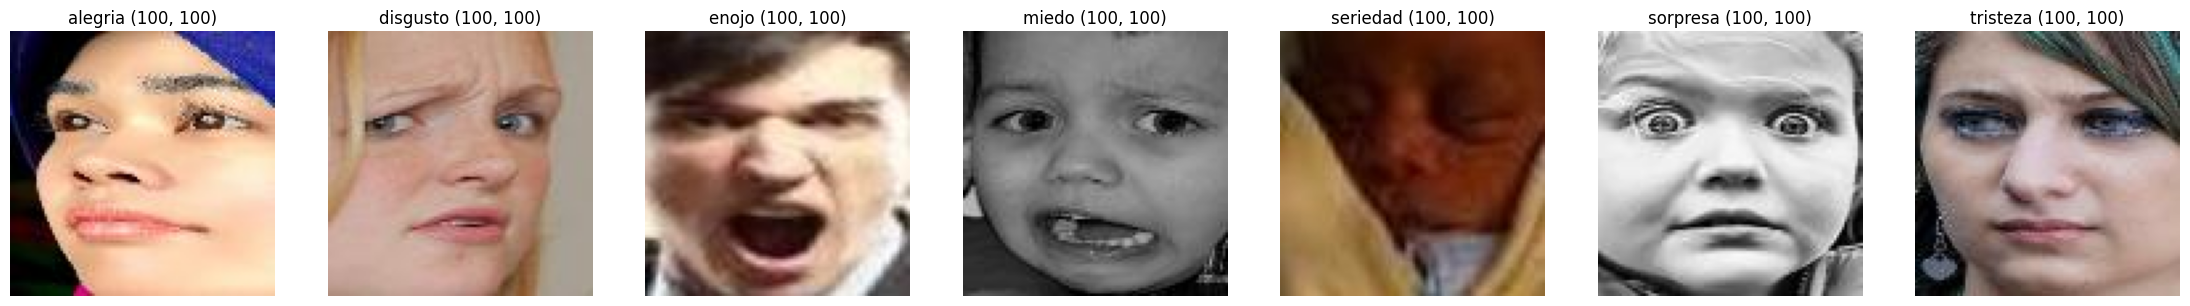

In [2]:
# 2. Exploración visual, dimensiones, canales
# Se usa un set para guardar dimensiones y canales para ver cuáles son los valores únicos
dimensiones = set()
canales = set()

fig, axes = plt.subplots(1, len(clases), figsize=(len(clases)*4, 4))

for i, c in enumerate(clases):
    ruta_clase = os.path.join(DATASET_ROOT_TRAIN, c)
    nombres_imgs = os.listdir(ruta_clase)

    # Para evaluar la primera imagen de cada clase
    img_path = os.path.join(ruta_clase, nombres_imgs[0])
    image = Image.open(img_path)

    dimensiones.add(image.size)
    canales.add(image.mode)

    axes[i].imshow(image, cmap='gray' if image.mode == 'L' else None)
    axes[i].set_title(f"{c} {image.size}")
    axes[i].axis('off')

    # Para evaluar todas las imágenes del dataset
    # for img in nombres_imgs:
    #     img_path = os.path.join(ruta_clase, img)
    #     image = Image.open(img_path)

    #     dimensiones.add(image.size)
    #     canales.add(image.mode)

print(f"Tamaños únicos encontrados (Ancho, Alto): {dimensiones}")
print(f"Modos de color únicos encontrados: {canales}")

# Encontrados:
# Tamaños únicos encontrados (Ancho, Alto): {(100, 100)}
# Modos de color únicos encontrados: {'RGB'}

El desbalance entre clases es muy grande. En el dataset de train los números son:
- alegria: 4772 imágenes
- disgusto: 717 imágenes
- enojo: 705 imágenes
- miedo: 281 imágenes
- seriedad: 2524 imágenes
- sorpresa: 1290 imágenes
- tristeza: 1982 imágenes

Será necesario tomar alguna acción para compensar esto, como ponderar las clases minoritarias o hacer algo de data augmentation. Se aplica una estrategia de data augmentation para prevenir el overfittind, pero no para aumentar la cantidad de imágenes en las clases minoritarias. Finalmente, para compensar el desbalance se considera apropiado penalizar más los errores directamente en la función de costo, de forma inversamente proporcional a las cantidades.

Las imágenes son todas cuadradas de 100x100 y en formato RGB. Sobre el color, se considera que aporta poca información para la detección de emociones, frente a rasgos como las líneas y texturas del rostro, por lo cual se convertirán a escala de grises.

In [3]:
from torchvision import transforms

# Preprocesamiento para train
transformaciones_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    # Se asegura el tamaño igualmente
    transforms.Resize((100, 100)),
    # Data augmentation para prevenir overfitting (no balancea clases)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    # Conversión a tensores
    transforms.ToTensor(),
    # Normalizar los datos al rango [-1, 1]
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# Preprocesamiento para validación (igual pero sin data augmentation obvio)
transformaciones_val = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

----

## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

#### Resolución

Se definen los siguientes criterios e hiperparámetros de la red, antes de empezar a configurarla:
- Función de activación -> ReLU, para evitar saturaciones como producen la tangente hiperbólica o la sigmoide.
- Optimizador y Learning Rate -> Adam (o AdamW) con lr=1e-3, es un punto de partida clásico. Si oscila mucho se probará con reducir el learning rate.
- Función de costo -> CrossEntropyLoss, adecuada para clasificación multiclase y aplica una LogSoftmax internamente
- Como capas de "extracción de features" se aplicarán 4 bloques convolucionales (cada bloque incluye: convolución con kernel size de 3, normalización en batch, ReLU, max pooling con kernel size de 2, dropout). El max pooling permitiría extraer características relevantes y reduce la resolución espacial a la mitad, por lo que en cada capa se duplicarán los canales para compensar, aumentando el mapa de caraterísticas.
- Como "clasificación" se implementan 2 capas: la primera se utiliza para representar las características de la salida multidimensional de las convoluciones en un vector de 256 (o quizás de 512), y la segunda para clasificar en una de las 7 clases de salida.

In [4]:
import torch
from torch import nn
from torchvision import datasets
from torch.utils.data import DataLoader
from torchinfo import summary

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [5]:
train_dataset = datasets.ImageFolder(DATASET_ROOT_TRAIN, transform=transformaciones_train)
val_dataset = datasets.ImageFolder(DATASET_ROOT_VAL, transform=transformaciones_val)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, pin_memory=True)

print(train_dataset.classes)

['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']


In [6]:
# Se calculan los pesos para las "balancear" las clases.
targets = torch.tensor(train_dataset.targets)

class_counts = torch.bincount(targets)
class_weights = targets.numel() / (len(class_counts) * class_counts.float())

class_weights

tensor([0.3674, 2.4449, 2.4865, 6.2384, 0.6945, 1.3589, 0.8845])

In [ ]:
def conv_block(c_in, c_out, dropout=0.1):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, kernel_size=3, padding=1), # Se conserva el tamaño de la imagen por defecto
        nn.BatchNorm2d(c_out), # Normaliza cada canal del batch (mejoraría estabilidad y acelera el entrenamiento)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2), # Se termina reduciendo a la mitad el tamaño en cada uso
        nn.Dropout2d(dropout)
    )

class CNN(nn.Module):
    def __init__(self, n_channels=1, n_output=7):
        super().__init__()

        # Input -> (batch, 1, 100, 100)
        self.features = nn.Sequential(
            conv_block(n_channels, 16, dropout=0.05), # (batch, 16, 50, 50)
            conv_block(16, 32, dropout=0.10), # (batch, 32, 25, 25)
            conv_block(32, 64, dropout=0.15), # (batch, 64, 12, 12)
            conv_block(64, 128, dropout=0.20), # (batch, 128, 6, 6)
        )

        # Al hacer el flatten pasa a ser 128 * 6 * 6
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_output)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Análisis dimensional
model = CNN().to(device)
summary(model, input_size=(64, 1, 100, 100))


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [64, 7]                   --
├─Sequential: 1-1                        [64, 128, 6, 6]           --
│    └─Sequential: 2-1                   [64, 16, 50, 50]          --
│    │    └─Conv2d: 3-1                  [64, 16, 100, 100]        160
│    │    └─BatchNorm2d: 3-2             [64, 16, 100, 100]        32
│    │    └─ReLU: 3-3                    [64, 16, 100, 100]        --
│    │    └─MaxPool2d: 3-4               [64, 16, 50, 50]          --
│    │    └─Dropout2d: 3-5               [64, 16, 50, 50]          --
│    └─Sequential: 2-2                   [64, 32, 25, 25]          --
│    │    └─Conv2d: 3-6                  [64, 32, 50, 50]          4,640
│    │    └─BatchNorm2d: 3-7             [64, 32, 50, 50]          64
│    │    └─ReLU: 3-8                    [64, 32, 50, 50]          --
│    │    └─MaxPool2d: 3-9               [64, 32, 25, 25]          --
│    │    └

In [27]:
from tqdm import tqdm
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
def fit(model, train_dataloader, val_dataloader, epochs=15):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    epoch_train_loss = []
    epoch_val_loss = []
    epoch_train_acc = []
    epoch_val_acc = []
    epoch_train_f1 = []
    epoch_val_f1 = []
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, train_acc, train_f1 = [], [], []
        bar = tqdm(train_dataloader)
        all_y, all_y_hat = [], []
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()

            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())

            all_y.extend(y.cpu().numpy())
            all_y_hat.extend(torch.argmax(y_hat, axis=1).cpu().numpy())

            bar.set_description(f"Train Loss: {np.mean(train_loss):.5f}")
        
        epoch_train_loss.append(np.mean(train_loss))
        train_accuracy = accuracy_score(all_y, all_y_hat)
        epoch_train_acc.append(train_accuracy)
        train_f1 = f1_score(all_y, all_y_hat, average='macro')
        epoch_train_f1.append(train_f1)

        # Validación
        bar = tqdm(val_dataloader)
        val_loss, val_acc = [], []

        model.eval()
        with torch.no_grad():
            all_y, all_y_hat = [], []
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)

                y_hat = model(X)
                loss = criterion(y_hat, y)
                val_loss.append(loss.item())

                all_y.extend(y.cpu().numpy())
                all_y_hat.extend(torch.argmax(y_hat, axis=1).cpu().numpy())
                
                bar.set_description(f"Val Loss: {np.mean(val_loss):.5f}")
            
        epoch_val_loss.append(np.mean(val_loss))
        val_accuracy = accuracy_score(all_y, all_y_hat)
        epoch_val_acc.append(val_accuracy)
        val_f1 = f1_score(all_y, all_y_hat, average='macro')
        epoch_val_f1.append(val_f1)
        
        print(f"Epoch {epoch}/{epochs}:")
        print(f" - Train Loss {np.mean(train_loss):.5f} | Val Loss {np.mean(val_loss):.5f}")
        print(f" - Train Acc {train_accuracy:.5f} | Val Acc {val_accuracy:.5f}")
        print(f" - Train F1 Macro {train_f1:.5f} | Val F1 Macro {val_f1:.5f}")

    plt.figure()
    plt.plot(epoch_train_loss, 'r', label='Train loss')
    plt.plot(epoch_val_loss, 'g', label='Validation loss')
    plt.title("Loss")
    plt.legend()
    plt.grid()

    plt.figure()
    plt.plot(epoch_train_acc, 'r', label='Train acc')
    plt.plot(epoch_val_acc, 'g', label='Validation acc')
    plt.title("Accuracy")
    plt.legend()
    plt.grid()

    plt.figure()
    plt.plot(epoch_train_f1, 'r', label='Train f1')
    plt.plot(epoch_val_f1, 'g', label='Validation f1')
    plt.title("F1 Macro")
    plt.legend()
    plt.grid()

    return (
        epoch_train_loss,
        epoch_val_loss,
        epoch_train_acc,
        epoch_val_acc,
        epoch_train_f1,
        epoch_val_f1
    )

In [34]:
epoch_train_loss, epoch_val_loss, epoch_train_acc, epoch_val_acc, epoch_train_f1, epoch_val_f1 = fit(model, train_dataloader, val_dataloader, 15)

  0%|          | 0/192 [00:00<?, ?it/s]c:\CEIA\TercerBimestre\AP\aprendizaje_profundo_ceia\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Train Loss: 0.78258: 100%|██████████| 192/192 [00:52<00:00,  3.69it/s]


TypeError: too many positional arguments

## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

image_path = ""

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6, minSize=(30,30))

image_with_box = image.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

cropped_face_rgb = None
if len(faces) > 0:
    (x, y, w, h) = faces[0]
    center_x, center_y = x + w // 2, y + h // 2
    side = max(w, h)
    half_side = side // 2

    x1 = max(center_x - half_side, 0)
    y1 = max(center_y - half_side, 0)
    x2 = min(center_x + half_side, image.shape[1])
    y2 = min(center_y + half_side, image.shape[0])

    cropped_face = image[y1:y2, x1:x2]
    cropped_face_rgb = cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB)

image_with_box_rgb = cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_with_box_rgb)
ax[0].set_title("Detección")
ax[0].axis('off')

if cropped_face_rgb is not None:
    ax[1].imshow(cropped_face_rgb)
    ax[1].set_title("Rostro recortado (relación aspecto 1:1)")
    ax[1].axis('off')
else:
    ax[1].text(0.5, 0.5, 'No se detectó rostro', horizontalalignment='center', verticalalignment='center')
    ax[1].axis('off')

plt.tight_layout()
plt.show()
